# TESSERA v2 pixel embeddings from Sentinel-1/2 via openEO

This notebook loads Sentinel-2 L2A and Sentinel-1 GRD (ascending + descending) through openEO, merges them into a single datacube, and runs the [TESSERA v2 "student"](https://github.com/ucam-eo/tessera) encoder (vendored PyTorch code) as a UDF to produce a 128-band pixel embedding. See [README.md](./README.md) for background and caveats.

The UDF needs PyTorch in the sandbox (installed via a `udf-dependency-archives` job option) and downloads a checkpoint by URL at runtime - see the "Build the UDF" and "Run the batch job" cells below.

In [1]:
import openeo
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

## Connect to the backend

Using the [Copernicus Data Space Ecosystem](https://dataspace.copernicus.eu/) openEO endpoint, which hosts both Sentinel-1 and Sentinel-2 collections.

In [2]:
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


## Define a small AOI and a one-year temporal extent

Keep the AOI small for a quick/cheap demo run - TESSERA embeddings are normally computed per calendar year.

In [3]:
spatial_extent = {
    "west": 5.13,
    "south": 51.20,
    "east": 5.16,
    "north": 51.22,
    "crs": 4326,
}
temporal_extent = ["2023-01-01", "2023-12-31"]

## Load Sentinel-2 and both Sentinel-1 orbits

S1 ascending/descending are loaded as separate cubes (filtered via `sat:orbit_state`) and their bands renamed, so that after `merge_cubes` we can tell all three sources apart by band name inside the UDF.

In [4]:
s2_bands = ["B04", "B02", "B03", "B08", "B8A", "B05", "B06", "B07", "B11", "B12", "SCL"]
s2_cube = connection.load_collection(
    "SENTINEL2_L2A",
    spatial_extent=spatial_extent,
    temporal_extent=temporal_extent,
    bands=s2_bands,
)


s1_asc = connection.load_collection(
    "SENTINEL1_GRD",
    spatial_extent=spatial_extent,
    temporal_extent=temporal_extent,
    bands=["VV", "VH"],
    properties={"sat:orbit_state": lambda v: v == "ASCENDING"},
)
s1_asc = s1_asc.rename_labels(dimension="bands", target=["VV_ASC", "VH_ASC"])
s1_asc = s1_asc.resample_cube_spatial(s2_cube, method = 'near')

s1_desc = connection.load_collection(
    "SENTINEL1_GRD",
    spatial_extent=spatial_extent,
    temporal_extent=temporal_extent,
    bands=["VV", "VH"],
    properties={"sat:orbit_state": lambda v: v == "DESCENDING"},
)
s1_desc = s1_desc.rename_labels(dimension="bands", target=["VV_DESC", "VH_DESC"])
s1_desc = s1_desc.resample_cube_spatial(s2_cube, method = 'near')

merged = s2_cube.merge_cubes(s1_asc).merge_cubes(s1_desc)

## Build the UDF

Replace `WEIGHTS_URL` with a direct URL to a TESSERA v2 student checkpoint (a `student_*.pt`
file), e.g. one of the `geotessera/TESSERA-V-2.0-2B-*` repos on the Hugging Face Hub:
`https://huggingface.co/geotessera/TESSERA-V-2.0-2B-N/resolve/main/ckpt/student_nano.pt`.
It must be publicly reachable over HTTPS - the UDF downloads it directly with `torch.load`.

In [5]:
WEIGHTS_URL = "https://huggingface.co/geotessera/TESSERA-V-2.0-2B-N/resolve/main/ckpt/student_nano.pt"  # TODO: pick a checkpoint

udf = openeo.UDF.from_file("udf_tessera_embedding.py", context={"weights_url": WEIGHTS_URL})
embedding_cube = merged.apply_dimension(process=udf, dimension="t", target_dimension="bands")

embedding_cube = embedding_cube.save_result(format="NetCDF")

## Run the batch job

The UDF uses real PyTorch (vendored from `tessera_infer_v2/student`), so torch must be installed
into the UDF sandbox via a `udf-dependency-archives` job option. The checkpoint itself is
downloaded by the UDF at runtime, via the `weights_url` passed in `context` above.

In [ ]:
job_options = {
    'driver-memory': '4g', 'executor-memory': '4g', 'executor-memoryOverhead': '4g', 'python-memory': '4g', 'soft-errors': 0.1,
    "udf-dependency-archives": [
        "https://s3.waw3-1.cloudferro.com/project_dependencies/torch_deps_python311.zip#feature_deps",
    ],
}

job = embedding_cube.execute_batch(
    "results/tessera_embedding.nc",
    title="TESSERA v2 embedding",
    job_options=job_options,
)

0:00:00 Job 'j-2609071512434b91a0025d80a4dd4bb7': send 'start'
0:00:05 Job 'j-2609071512434b91a0025d80a4dd4bb7': queued (progress 0%)
0:00:10 Job 'j-2609071512434b91a0025d80a4dd4bb7': queued (progress 0%)
0:00:17 Job 'j-2609071512434b91a0025d80a4dd4bb7': queued (progress 0%)
0:00:25 Job 'j-2609071512434b91a0025d80a4dd4bb7': queued (progress 0%)
0:00:34 Job 'j-2609071512434b91a0025d80a4dd4bb7': queued (progress 0%)
0:00:47 Job 'j-2609071512434b91a0025d80a4dd4bb7': queued (progress 0%)
0:01:02 Job 'j-2609071512434b91a0025d80a4dd4bb7': queued (progress 0%)
0:01:22 Job 'j-2609071512434b91a0025d80a4dd4bb7': running (progress N/A)
0:01:46 Job 'j-2609071512434b91a0025d80a4dd4bb7': running (progress N/A)
0:02:16 Job 'j-2609071512434b91a0025d80a4dd4bb7': running (progress N/A)
0:02:53 Job 'j-2609071512434b91a0025d80a4dd4bb7': running (progress N/A)
0:03:40 Job 'j-2609071512434b91a0025d80a4dd4bb7': running (progress N/A)
0:04:39 Job 'j-2609071512434b91a0025d80a4dd4bb7': running (progress N/A)
0:

Download the results

In [13]:
results  = job.get_results()

results.download_files("output")

[WindowsPath('output/openEO.nc'), WindowsPath('output/job-results.json')]

## Visualize the embedding (PCA to RGB)

The 128-d embedding isn't directly viewable, so reduce it to 3 principal components for a quick visual sanity check (same approach as [../DimensionalityReduction](../DimensionalityReduction)).

(np.float64(-0.5), np.float64(216.5), np.float64(228.5), np.float64(-0.5))

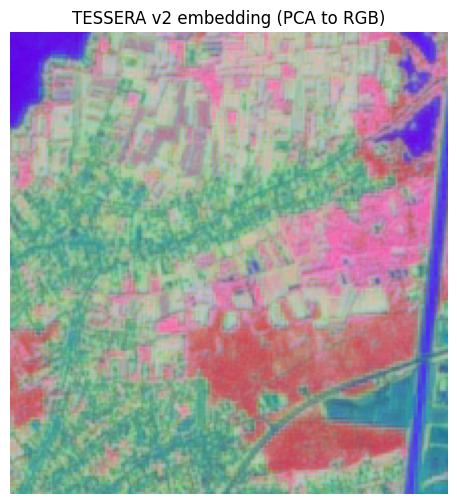

In [17]:
output = xr.open_dataset("output/openEO.nc")
output = output.drop_vars('crs')

arr = output.to_array(dim="bands").squeeze()  # (bands, y, x)

flat = arr.values.reshape(arr.shape[0], -1).T  # (pixels, bands)
flat = flat - flat.mean(axis=0, keepdims=True)
u, s, vt = np.linalg.svd(flat, full_matrices=False)
rgb = (u[:, :3] * s[:3]).reshape(arr.shape[1], arr.shape[2], 3)
rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())

plt.figure(figsize=(6, 6))
plt.imshow(rgb)
plt.title("TESSERA v2 embedding (PCA to RGB)")
plt.axis("off")